<table>
<tr>
<td><img src="https://raw.githubusercontent.com/RafaelCaballero/APD/refs/heads/main/img/logoAPD.png" width="150"></td>
<td><table><tr><td><h1>Estadística descriptiva de una variable</h1></td></tr>
           <tr><td><h3>Rafael Caballero Roldán</h3></td></tr></table></td>
<td><img src="https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcTsPjCdm67xYS9AM7-dXQ46O23vaexAhnVJaQ&s" width="105"></td>
</tr>
</table>



# Tabla de Contenidos
1. [Primer vistazo con Pandas](#1.-Primer-vistazo-con-Pandas)<br>
   1.1 [Información básica](#1.1-Información-básica)<br>
   1.2 [Tipos de variables](#1.2-Tipos-de-variables)<br>
   1.3 [Información básica mediante librerías](#1.3-Información-básica-mediante-librerías)<br>  
2. [Medidas de centralidad](#2.-Medidas-de-centralidad)<br>

3. [Medidas de dispersión](#3.-Medidas-de-dispersión)<br>

4. [Representación gráfica](#4.-Representación-gráfica)<br>
   4.1 [Histogramas y diagramas de barras](#4.1-Histogramas-y-diagramas-de-barras)<br>
   4.2 [Diagramas de líneas](#4.2-Diagramas-de-líneas)<br>

5. [Referencias](#Referencias)<br>




Ejecutar el código siguiente para asegurarse de que están todas las librerías instaladas. Si se instala alguna nueva suele ser buena idea dar a Kernel+Restart Kernel y volver a ejecutar esta casilla (algunos módulos puede poner que siguen sin estar instalados, pero no precuparse de este alarmante mensaje, sí lo están)

In [ ]:
modules = ["ydata-sdk","sweetviz","ydata_profiling", "PyQt6","plotly","seaborn","ipywidgets"]
modules = ["matplotlib","pandas","numpy", "PyQt6","plotly","seaborn","ipywidgets"]

import sys
import os.path
from subprocess import check_call
import importlib
import os

def instala(modules):
    print("Instalando módulos")
    for m in modules:
        # para el import quitamos [...] y ==...
        p = m.find("[")
        mi = m if p==-1 else m[:p]
        p = mi.find("==")
        mi = mi if p==-1 else mi[:p]
        torch_loader = importlib.util.find_spec(mi)
        if torch_loader is not None:
            print(m," encontrado")
        else:
            print(m," No encontrado, instalando...",end="")
            try:
                r = check_call([sys.executable, "-m", "pip", "install", "--user", m])
                print("¡hecho!")
            except:
                print("¡Problema al instalar ",m,"! ¿seguro que el módulo existe?",sep="")

    print("¡Terminado!")

instala(modules)

Instalando módulos
matplotlib  encontrado
pandas  encontrado
numpy  encontrado
PyQt6  encontrado
plotly  encontrado
seaborn  encontrado
ipywidgets  encontrado
¡Terminado!


## 1. Primer vistazo con Pandas
---

Cuando nos lleguen datos nuestro primer objetivo debe ser **entender los datos**: el significado de cada columna, las relaciones entre ellas, la cantidad de nulos, etc.

Para esto nos ayudaremos de observaciones y gráficas

Hay que intentar ser _neutral_ al principio: investigarlo todo por si surgen relaciones insospechadas: todo conocimiento "a priori" que tengamos puede impedirnos descubrir información interesante. No limitarse a lo que se refiere a nuestro objetivo final, examinar los datos sin prisa y sin restar importancia a ninguno de ellos.

De este conocimiento inicial surgirán datos importantes para el posterior preprocesamiento

Estaría muy bien crear un diccionario de datos

| **Nombre del Campo** | **Descripción**           | **Tipo de Datos**     | **Formato / Ejemplo**   | **Valores Posibles / Rango** | **Nulos Permitidos** | **Comentarios**                 | **Tipo Semántico**     |
|----------------------|---------------------------|-----------------------|-------------------------|-----------------------------|----------------------|---------------------------------|------------------------|
| `id_cliente`         | Identificador único del cliente | Entero (int)         | 123456                  | N/A                         | No                   | Clave primaria, sin duplicados. | Categórico             |
| `edad`               | Edad del cliente          | Entero (int)          | 25                      | 0 - 120                     | Sí                   | Puede contener valores nulos si no está disponible. | Ratio                 |
| `genero`             | Género del cliente        | Categoría (string)    | 'M' / 'F'               | 'M', 'F'                    | No                   | M = Masculino, F = Femenino.    | Categórico             |
| `ingreso_anual`      | Ingreso anual en euros    | Float                 | 35000.50                | 0 - 1,000,000               | Sí                   | En euros, algunos registros pueden estar faltantes. | Ratio                 |
| `fecha_registro`     | Fecha de registro         | Fecha (date)          | '2022-04-15'            | N/A                         | No                   | Formato ISO 'YYYY-MM-DD'.       | Intervalo              |
| `tipo_cliente`       | Categoría del cliente     | Categoría (string)    | 'Regular', 'VIP'        | 'Regular', 'VIP', 'Nuevo'   | No                   | Determina nivel de servicio.    | Categórico/Ordinal     |
| `compras_totales`    | Número total de compras   | Entero (int)          | 12                      | 0 - N/A                     | No                   | Incluye todas las compras realizadas. | Ratio             |
| `suscrito_boletin`   | Suscripción al boletín    | Booleano (bool)       | True / False            | True, False                 | No                   | True si está suscrito.          | Categórico             |


### 1.1 Información básica

Veamos algunas funciones útiles de Pandas mediante un ejemplo.

In [ ]:
import pandas as pd

url = "https://raw.githubusercontent.com/RafaelCaballero/tdm/refs/heads/master/datos/madrid/contaminacionLargo.csv"

df = pd.read_csv(url)
df.to_csv("contaminacionLargo.csv",index=False)
df

,ANO,MES,DIA,HORA,CO,NO,NO2,PM2.5,PM10,NOx,O3,fechaH,fecha,festivo
0,2019.0,1.0,1.0,1.0,0.6,81.0,73.0,NaN,NaN,196,3.08,2019-01-01 00:00:00,2019-01-01 00:00:00,festivo
1,2019.0,1.0,1.0,2.0,0.8,124.0,82.0,NaN,NaN,272,3.05,2019-01-01 01:00:00,2019-01-01 00:00:00,festivo
2,2019.0,1.0,1.0,3.0,0.7,93.0,72.0,NaN,NaN,215,3.13,2019-01-01 02:00:00,2019-01-01 00:00:00,festivo
3,2019.0,1.0,1.0,4.0,0.6,86.0,66.0,NaN,NaN,198,3.02,2019-01-01 03:00:00,2019-01-01 00:00:00,festivo
4,2019.0,1.0,1.0,5.0,0.6,79.0,64.0,NaN,NaN,185,2.98,2019-01-01 04:00:00,2019-01-01 00:00:00,festivo
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24021,2021.0,9.0,30.0,20.0,0.3,27.0,80.0,17.0,23.0,122,NaN,2021-09-30 19:00:00,2021-09-30 00:00:00,laborable
24022,2021.0,9.0,30.0,21.0,1.1,168.0,153.0,19.0,30.0,411,NaN,2021-09-30 20:00:00,2021-09-30 00:00:00,laborable
24023,2021.0,9.0,30.0,22.0,1.0,179.0,157.0,28.0,44.0,431,NaN,2021-09-30 21:00:00,2021-09-30 00:00:00,laborable
24024,2021.0,9.0,30.0,23.0,0.8,115.0,133.0,27.0,43.0,309,NaN,2021-09-30 22:00:00,2021-09-30 00:00:00,laborable


El número de filas y columnas se puede extraer por ejemplo de `shape`:

In [ ]:
f,c = df.shape
print(f"El dataframe tiene {f} filas y {c} columnas")

El dataframe tiene 24026 filas y 14 columnas


Lo primero que solemos hacer es utlizar `info()`

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24026 entries, 0 to 24025
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   ANO      23944 non-null  float64
 1   MES      23962 non-null  float64
 2   DIA      23962 non-null  float64
 3   HORA     23970 non-null  float64
 4   CO       23615 non-null  float64
 5   NO       23963 non-null  float64
 6   NO2      23907 non-null  float64
 7   PM2.5    18993 non-null  float64
 8   PM10     18993 non-null  float64
 9   NOx      24026 non-null  int64  
 10  O3       20864 non-null  float64
 11  fechaH   24026 non-null  object 
 12  fecha    24026 non-null  object 
 13  festivo  24026 non-null  object 
dtypes: float64(10), int64(1), object(3)
memory usage: 2.6+ MB


`info()`es útil, pero el problema es que la información no se puede trtar por programa (solo muestra, no devuelve nada). Podemos hacernos nuestro propio info:

In [ ]:
def info_df(df):
    return pd.DataFrame({
    'Columna': df.columns,
    'No Nulos': df.notnull().sum().values,
    'Nulos': df.isnull().sum().values,
    'Tipo Python': df.dtypes.values,
    'Núm. valores': [len(df[col].unique()) for col in df.columns]
     })
info = info_df(df)
info

,Columna,No Nulos,Nulos,Tipo Python,Núm. valores
0,ANO,23944,82,float64,4
1,MES,23962,64,float64,13
2,DIA,23962,64,float64,32
3,HORA,23970,56,float64,25
4,CO,23615,411,float64,28
5,NO,23963,63,float64,380
6,NO2,23907,119,float64,232
7,PM2.5,18993,5033,float64,79
8,PM10,18993,5033,float64,115
9,NOx,24026,0,int64,669


Podemos exportar esta información para completarlo posteriormente en el diccionario de datos

In [ ]:
info.to_excel("diccionario.xlsx",index=False)

En el caso de que el número de valores de una columna no sea excesivamente alto podemos mostrar cada uno de ellos y su frecuencia

In [ ]:
for col in df.columns:
    if len(df[col].unique())<30:
        print(df[col].value_counts())
        print("="*50)

ANO
2020.0    8747
2019.0    8668
2021.0    6529
Name: count, dtype: int64
MES
5.0     2231
3.0     2229
1.0     2225
8.0     2218
7.0     2200
4.0     2158
9.0     2158
6.0     2100
2.0     2033
10.0    1485
12.0    1485
11.0    1440
Name: count, dtype: int64
HORA
1.0     1002
24.0    1002
23.0    1002
2.0     1001
22.0    1001
15.0    1000
14.0     999
17.0     999
21.0     999
19.0     999
16.0     999
18.0     999
5.0      998
8.0      998
9.0      998
10.0     998
12.0     998
13.0     998
4.0      997
6.0      997
11.0     997
7.0      997
20.0     997
3.0      995
Name: count, dtype: int64
CO
0.2    9052
0.3    5790
0.1    2624
0.4    2439
0.5    1276
0.6     745
0.7     550
0.8     369
0.9     221
1.0     136
1.1     101
1.2      62
1.4      47
1.3      43
0.0      39
1.5      32
1.7      22
1.6      18
1.8      13
1.9      13
2.0       5
2.2       5
2.3       4
2.1       4
2.4       2
2.6       2
2.8       1
Name: count, dtype: int64
festivo
laborable    23114
festivo        8

### 1.2 Tipos de variables

Vemos que Python divide las columnas, de forma muy burda,  en numéricas y no numéricas. Nosotros podemos mejorar esto aprovechando los recursos del lenguaje y observando y comprendiendo los datos

![image.png](attachment:57aa1add-b844-41cf-b75f-738bac4aae60.png)
<br>


**Fechas**

En el caso de los tipos fecha podemos cargarlos directamente como fechas:


In [ ]:
import pandas as pd
url = "https://raw.githubusercontent.com/RafaelCaballero/tdm/refs/heads/master/datos/madrid/contaminacionLargo.csv"
df = pd.read_csv(url,parse_dates=['fechaH','fecha'])
df

,ANO,MES,DIA,HORA,CO,NO,NO2,PM2.5,PM10,NOx,O3,fechaH,fecha,festivo
0,2019.0,1.0,1.0,1.0,0.6,81.0,73.0,NaN,NaN,196,3.08,2019-01-01 00:00:00,2019-01-01,festivo
1,2019.0,1.0,1.0,2.0,0.8,124.0,82.0,NaN,NaN,272,3.05,2019-01-01 01:00:00,2019-01-01,festivo
2,2019.0,1.0,1.0,3.0,0.7,93.0,72.0,NaN,NaN,215,3.13,2019-01-01 02:00:00,2019-01-01,festivo
3,2019.0,1.0,1.0,4.0,0.6,86.0,66.0,NaN,NaN,198,3.02,2019-01-01 03:00:00,2019-01-01,festivo
4,2019.0,1.0,1.0,5.0,0.6,79.0,64.0,NaN,NaN,185,2.98,2019-01-01 04:00:00,2019-01-01,festivo
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24021,2021.0,9.0,30.0,20.0,0.3,27.0,80.0,17.0,23.0,122,NaN,2021-09-30 19:00:00,2021-09-30,laborable
24022,2021.0,9.0,30.0,21.0,1.1,168.0,153.0,19.0,30.0,411,NaN,2021-09-30 20:00:00,2021-09-30,laborable
24023,2021.0,9.0,30.0,22.0,1.0,179.0,157.0,28.0,44.0,431,NaN,2021-09-30 21:00:00,2021-09-30,laborable
24024,2021.0,9.0,30.0,23.0,0.8,115.0,133.0,27.0,43.0,309,NaN,2021-09-30 22:00:00,2021-09-30,laborable


In [ ]:
info = info_df(df)
info

,Columna,No Nulos,Nulos,Tipo Python,Núm. valores
0,ANO,23944,82,float64,4
1,MES,23962,64,float64,13
2,DIA,23962,64,float64,32
3,HORA,23970,56,float64,25
4,CO,23615,411,float64,28
5,NO,23963,63,float64,380
6,NO2,23907,119,float64,232
7,PM2.5,18993,5033,float64,79
8,PM10,18993,5033,float64,115
9,NOx,24026,0,int64,669


Tener el tipo fecha da ciertas ventajas, como poder acceder a sus componentes o utilizarlo de índice para dibujar

In [ ]:
# No olvidar el accesor dt para fecha y str para string...cosas de Pandas
df.fecha.dt.year

0        2019
1        2019
2        2019
3        2019
4        2019
         ... 
24021    2021
24022    2021
24023    2021
24024    2021
24025    2021
Name: fecha, Length: 24026, dtype: int32

In [ ]:
df.columns

Index(['ANO', 'MES', 'DIA', 'HORA', 'CO', 'NO', 'NO2', 'PM2.5', 'PM10', 'NOx',
       'O3', 'fechaH', 'fecha', 'festivo'],
      dtype='object')

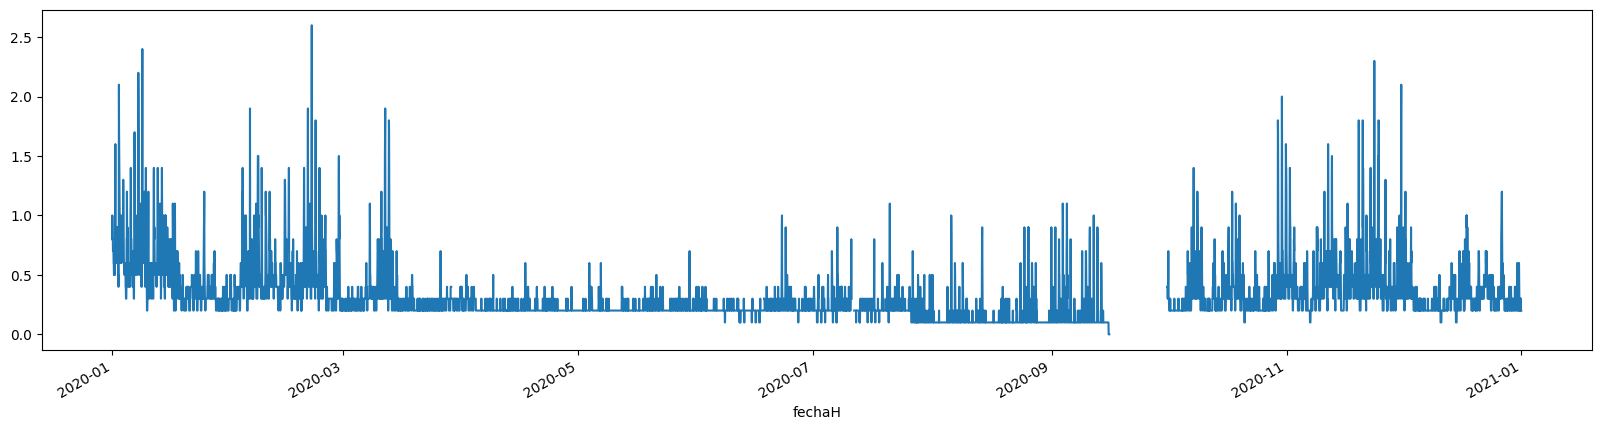

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
df.index = df.fechaH

#### figura
plt.figure(figsize=(20, 5)) # crea el marco donde irá la figura
df[df.fechaH.dt.year==2020].CO.plot()
plt.show()

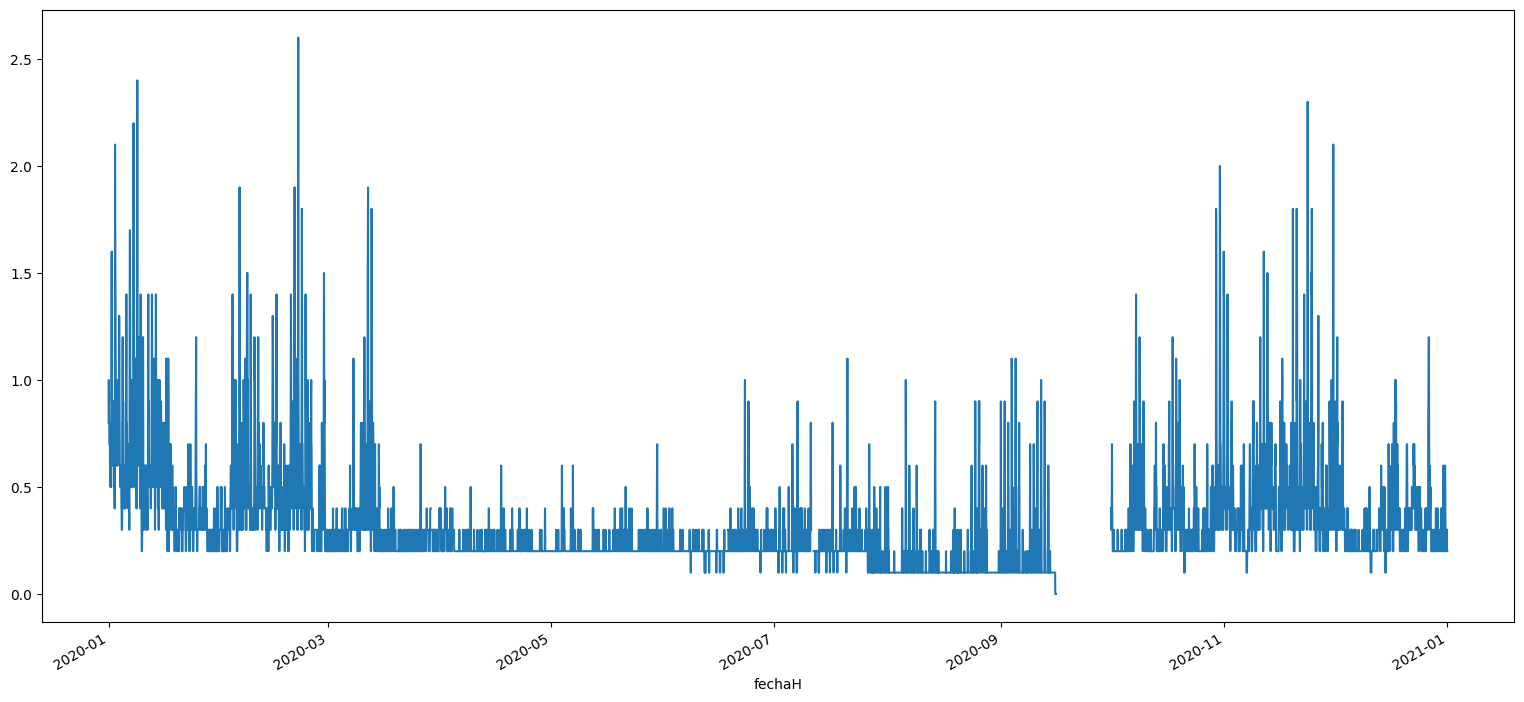

In [ ]:
# otra forma
import pandas as pd
import matplotlib.pyplot as plt
df.index = df.fechaH
df[df.fechaH.dt.year==2020].CO.plot(figsize=(19,9))
plt.show()

In [ ]:
df.CO

fechaH
2019-01-01 00:00:00    0.6
2019-01-01 01:00:00    0.8
2019-01-01 02:00:00    0.7
2019-01-01 03:00:00    0.6
2019-01-01 04:00:00    0.6
                      ... 
2021-09-30 19:00:00    0.3
2021-09-30 20:00:00    1.1
2021-09-30 21:00:00    1.0
2021-09-30 22:00:00    0.8
2021-09-30 23:00:00    0.4
Name: CO, Length: 24026, dtype: float64

La función `describe()` se suele usar para obtener información básica sobre las columnas numéricas (y fecha)

In [ ]:
df.describe()

,ANO,MES,DIA,HORA,CO,NO,NO2,PM2.5,PM10,NOx,O3,fechaH,fecha
count,23944.000000,23962.000000,23962.000000,23970.000000,23615.000000,23963.000000,23907.000000,18993.000000,18993.000000,24026.000000,20864.000000,24026,24026
mean,2019.910667,6.111385,15.702237,12.504881,0.313631,29.286066,44.520392,10.588796,16.393935,89.095230,45.805475,2020-05-17 16:39:19.194206208,2020-05-21 23:14:55.729626112
min,2019.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2019-01-01 00:00:00,2019-01-01 00:00:00
25%,2019.000000,3.000000,8.000000,7.000000,0.200000,6.000000,22.000000,5.000000,8.000000,33.000000,17.580000,2019-09-10 15:15:00,2019-09-10 00:00:00
50%,2020.000000,6.000000,16.000000,13.000000,0.300000,13.000000,37.000000,9.000000,13.000000,58.000000,46.560000,2020-05-18 02:30:00,2020-05-18 00:00:00
75%,2021.000000,9.000000,23.000000,19.000000,0.400000,31.000000,59.000000,14.000000,21.000000,107.000000,68.782500,2021-01-23 10:45:00,2021-01-26 00:00:00
max,2021.000000,12.000000,31.000000,24.000000,2.800000,584.000000,261.000000,88.000000,157.000000,1136.000000,423.400000,2021-09-30 23:00:00,2021-12-09 00:00:00
std,0.791666,3.309840,8.778520,6.925210,0.220443,46.894668,31.210870,8.507110,12.916858,97.808241,29.957961,NaN,NaN


In [ ]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
ANO,23944.0,2019.910667,2019.0,2019.0,2020.0,2021.0,2021.0,0.791666
MES,23962.0,6.111385,1.0,3.0,6.0,9.0,12.0,3.30984
DIA,23962.0,15.702237,1.0,8.0,16.0,23.0,31.0,8.77852
HORA,23970.0,12.504881,1.0,7.0,13.0,19.0,24.0,6.92521
CO,23615.0,0.313631,0.0,0.2,0.3,0.4,2.8,0.220443
NO,23963.0,29.286066,0.0,6.0,13.0,31.0,584.0,46.894668
NO2,23907.0,44.520392,0.0,22.0,37.0,59.0,261.0,31.21087
PM2.5,18993.0,10.588796,0.0,5.0,9.0,14.0,88.0,8.50711
PM10,18993.0,16.393935,0.0,8.0,13.0,21.0,157.0,12.916858
NOx,24026.0,89.09523,0.0,33.0,58.0,107.0,1136.0,97.808241


### 1.3 Información básica mediante librerías

Con una librería adecuada se puede conseguir mucha información a la vez en forma de informe. Son una excelente forma de tener un priemr vistazo muy completo. Ver  ydata-sdk, ydata_profiling, sweetviz

In [ ]:
import pandas as pd
url = "https://raw.githubusercontent.com/RafaelCaballero/tdm/refs/heads/master/datos/madrid/contaminacionLargo.csv"
df = pd.read_csv(url,parse_dates=['fechaH','fecha'])
df

,ANO,MES,DIA,HORA,CO,NO,NO2,PM2.5,PM10,NOx,O3,fechaH,fecha,festivo
0,2019.0,1.0,1.0,1.0,0.6,81.0,73.0,NaN,NaN,196,3.08,2019-01-01 00:00:00,2019-01-01,festivo
1,2019.0,1.0,1.0,2.0,0.8,124.0,82.0,NaN,NaN,272,3.05,2019-01-01 01:00:00,2019-01-01,festivo
2,2019.0,1.0,1.0,3.0,0.7,93.0,72.0,NaN,NaN,215,3.13,2019-01-01 02:00:00,2019-01-01,festivo
3,2019.0,1.0,1.0,4.0,0.6,86.0,66.0,NaN,NaN,198,3.02,2019-01-01 03:00:00,2019-01-01,festivo
4,2019.0,1.0,1.0,5.0,0.6,79.0,64.0,NaN,NaN,185,2.98,2019-01-01 04:00:00,2019-01-01,festivo
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24021,2021.0,9.0,30.0,20.0,0.3,27.0,80.0,17.0,23.0,122,NaN,2021-09-30 19:00:00,2021-09-30,laborable
24022,2021.0,9.0,30.0,21.0,1.1,168.0,153.0,19.0,30.0,411,NaN,2021-09-30 20:00:00,2021-09-30,laborable
24023,2021.0,9.0,30.0,22.0,1.0,179.0,157.0,28.0,44.0,431,NaN,2021-09-30 21:00:00,2021-09-30,laborable
24024,2021.0,9.0,30.0,23.0,0.8,115.0,133.0,27.0,43.0,309,NaN,2021-09-30 22:00:00,2021-09-30,laborable


In [ ]:
"""
from ydata_profiling import ProfileReport
profile = ProfileReport(df)
profile.to_notebook_iframe()
profile.to_file("contamina.html")
"""

'\nfrom ydata_profiling import ProfileReport\nprofile = ProfileReport(df)\nprofile.to_notebook_iframe()\nprofile.to_file("contamina.html")\n'

Otras posibilidades

In [ ]:
"""
import sweetviz as sv
report = sv.analyze(df)
report.show_html()
"""

'\nimport sweetviz as sv\nreport = sv.analyze(df)\nreport.show_html()\n'

## 2. Medidas de centralidad
---

La idea de las medidas de centralidad es reducir toda la columna a un solo número un "centro", el que mejor la represente. En la práctica hay más de una posibilidad.


* Moda: el valor que más se repite. La única medida que tiene sentido para variables categóricas.

* Media: $\mu(x) = \frac{\displaystyle {\sum_{i=1}^{N} x_i}}{N}$, donde $x$ es la variable que estamos estudiando formada por $x_1, \dots, x_N$. La media es la medida de centralidad más popular. Puede verse afectada si hay hay una proporción grande de valores demasiado grandes o pequeños (outliers), especialmente si estos están agrupados de forma desigual.

* Mediana: valor que deja al 50% de los valores por debajo y el otro 50% por encima.

Para ver qué medida de centralidad es aplicable en cada caso tenemos que considerar el tipo de variable y si es discreta o continua:

| **Tipo de Variable**     | **Nominal**                  | **Ordinal**                  | **Intervalo**                | **Ratio**                    |
|--------------------------|------------------------------|------------------------------|------------------------------|------------------------------|
| **Discreta**             | Moda                         | Moda, Mediana                | Moda, Mediana, Media?         | Moda, Mediana, Media?       |
| **Continua**             | No aplica                    | Moda, Mediana                | Moda, Mediana, Media         | Moda, Mediana, Media        
Esta tabla es una buena referencia, pero después hay que mirar cada caso.

**Ejemplo 1** En un valor bursátil que normalmente sube salvo pequeñas bajadas ¿tiene sentido hablar de la moda?

**Ejemplo 2** Tenemos un dataframes con datos de tweets. Una columna que indica la hora a la que se produce el tweet. En nuestro caso casi todos se producen por la noche, más o menos la mitad a las 23h y la mitad a las 0h. ¿Cuál será la media? ¿tiene sentido?

Para obtener estos resultados con Pandas podemos utilizar los métodos predefinidos `mode`, `median` y `mean`.

Vamos a cargar los datos que hemos visto antes para analizar cada uno de estos valores:
 |


In [ ]:
import pandas as pd
import numpy as np
from pandas.api.types import CategoricalDtype

def info_df(df):
    return pd.DataFrame({
    'Columna': df.columns,
    'No Nulos': df.notnull().sum().values,
    'Nulos': df.isnull().sum().values,
    'Tipo Python': df.dtypes.values,
    'Núm. valores': [len(df[col].unique()) for col in df.columns]
     })

def carga_conta():
    # cargamos datos, teniendo en cuenta las fechas
    url = "https://raw.githubusercontent.com/RafaelCaballero/tdm/refs/heads/master/datos/madrid/contaminacionLargo.csv"
    df = pd.read_csv(url,parse_dates=['fechaH','fecha'])

    # índice la fecha con hora
    df.index = df.fechaH

    # columnas categóricas
    columnas = ["ANO","MES","DIA","HORA"]
    for col in columnas:
        valores = np.sort(df[col].dropna().unique()) # lista de valores únicos ordenados, sin null
        cat_type = CategoricalDtype(categories=valores, ordered=True) # estos son todos ordenados, se puede hacer -,+. max(),min(), pero no mean()
        df[col] = df[col].astype(cat_type)

    # en festivo no hay orden; no queremos que se pueda hacer min ni max
    col = "festivo"
    valores = np.sort(df[col].unique())
    cat_type = CategoricalDtype(categories=valores, ordered=False)
    df[col] = df[col].astype(cat_type)
    return df

df = carga_conta()
info = info_df(df)
info

,Columna,No Nulos,Nulos,Tipo Python,Núm. valores
0,ANO,23944,82,category,4
1,MES,23962,64,category,13
2,DIA,23962,64,category,32
3,HORA,23970,56,category,25
4,CO,23615,411,float64,28
5,NO,23963,63,float64,380
6,NO2,23907,119,float64,232
7,PM2.5,18993,5033,float64,79
8,PM10,18993,5033,float64,115
9,NOx,24026,0,int64,669


In [ ]:
# Valor que más veces aparece en la columna festivo
df.festivo.mode()


0    laborable
Name: festivo, dtype: category
Categories (4, object): ['domingo', 'festivo', 'laborable', 'sábado']

In [ ]:
# la moda puede devolver varios resultados porque dos o más valores se repitan la misma cantidad de veces
df.fechaH.mode()

0       2019-01-01 00:00:00
1       2019-01-01 01:00:00
2       2019-01-01 02:00:00
3       2019-01-01 03:00:00
4       2019-01-01 04:00:00
                ...        
24021   2021-09-30 19:00:00
24022   2021-09-30 20:00:00
24023   2021-09-30 21:00:00
24024   2021-09-30 22:00:00
24025   2021-09-30 23:00:00
Name: fechaH, Length: 24026, dtype: datetime64[ns]

Código para ver la  moda de cada columna y su importancia

In [ ]:
# mostramos solo el primer valor en cada caso, con el número de repeticiones
header = f"{'Columna':<10} {'Moda':<20} {'Frecuencia':<10} {'% sobre no nulos':<15}"
print(header)
print("-" * len(header))
for col in df.columns:
    columna = df[col].dropna() # quitamos los nulos porque luego vamos a contar el número de filas
    frecuencias = df[col].value_counts()
    moda = frecuencias.index[0] if not df[col].mode().empty else None
    non_null_count = df[col].notnull().sum()
    moda_count = frecuencias.values[0]
    moda_percentage = (moda_count / non_null_count * 100) if non_null_count > 0 else 0
    print(f"{col:<10} {str(moda):<20} {moda_count:<10} {round(moda_percentage,2):<15}")

Columna    Moda                 Frecuencia % sobre no nulos
-----------------------------------------------------------
ANO        2020.0               8747       36.53          
MES        5.0                  2231       9.31           
DIA        13.0                 792        3.31           
HORA       1.0                  1002       4.18           
CO         0.2                  9052       38.33          
NO         5.0                  1417       5.91           
NO2        29.0                 441        1.84           
PM2.5      4.0                  1272       6.7            
PM10       10.0                 942        4.96           
NOx        39                   309        1.29           
O3         0.0                  119        0.57           
fechaH     2019-01-01 00:00:00  1          0.0            
fecha      2021-09-30 00:00:00  24         0.1            
festivo    laborable            23114      96.2           


In [ ]:
# código para obtener las columnas numéricas.
columnas_numéricas = df.select_dtypes(include=['number']).columns.tolist()

header = f"{'Columna':<30} {'Mediana':<10} {'Media':<10}"
print(header)
print("-" * len(header))
for col in columnas_numéricas:
    media = df[col].mean()
    median = df[col].median()
    print(f"{col:<30} {round(media,2):<10} {round(median,2):<10}")


Columna                        Mediana    Media     
----------------------------------------------------
CO                             0.31       0.3       
NO                             29.29      13.0      
NO2                            44.52      37.0      
PM2.5                          10.59      9.0       
PM10                           16.39      13.0      
NOx                            89.1       58.0      
O3                             45.81      46.56     


En este caso podríamos haber usado describe, es más sencillo


In [ ]:
df.describe().T[["mean","50%"]],2

(                                 mean                  50%
 CO                           0.313631                  0.3
 NO                          29.286066                 13.0
 NO2                         44.520392                 37.0
 PM2.5                       10.588796                  9.0
 PM10                        16.393935                 13.0
 NOx                          89.09523                 58.0
 O3                          45.805475                46.56
 fechaH  2020-05-17 16:39:19.194206208  2020-05-18 02:30:00
 fecha   2020-05-21 23:14:55.729626112  2020-05-18 00:00:00,
 2)

En los casos en los que la media es muy diferente de la mediana (NO,NOx) e indica que tenemos una distribución fuertemente asimétrica (en la dirección indicada por la media), ya que la media se ve más afectada por valores extremos, mientras que la mediana es más robusta --> podemos deducir que posiblemente se alcanzan valores muy altos de NO y NOx

**Ejemplo**

Calcular (a mano) la media y la mediana de 1,2,3 y 1,2,996

En distribuciones asimétricas la mediana es la medida de centralidad preferida

## 3. Medidas de dispersión
---

Si las medidas de centralidad dan la idea de un "centro" de la variable, la media de dispersión sería el "radio" indica lo alejados que están de ese centro. Vamos a ver dos, cada una relacionado con una de las medidas de centralidad

* Desviación típica $\sigma(x)=\sqrt{\frac{{\displaystyle \sum_{i=1}^{N}\left(x_{i}-\mu\right)^{2}}}{N}}$, la raíz cuadrada de la varianza

* Desviación absoluta con respecto a la mediana $\mathit{MAD}(x) = mediana(|x_i - mediana(x)|)$

En los casos en los que sospechemos que hay muchos valores extremos, si elegimos la mediana también deberíamos seleccionar el MAD



In [ ]:
df.NOx.std(), (df.NOx - df.NOx.median()).abs().median()

(np.float64(97.80824113465822), np.float64(31.0))

In [ ]:
from scipy.stats import median_abs_deviation
df.NOx.std(), median_abs_deviation(df.NOx)

(np.float64(97.80824113465822), np.float64(31.0))

## 4. Representación gráfica
---

Veamos diferentes representaciones gráficas típicas de los datos

### 4.1 Histogramas y diagramas de barras

Muestran la frecuencia (número de repeticiones) de cada valor.

- Histograma: para variables continuas. Se utilizan intervalos (los bins)
- Diagrama de barras: para variables discretas.

La forma más sencilla

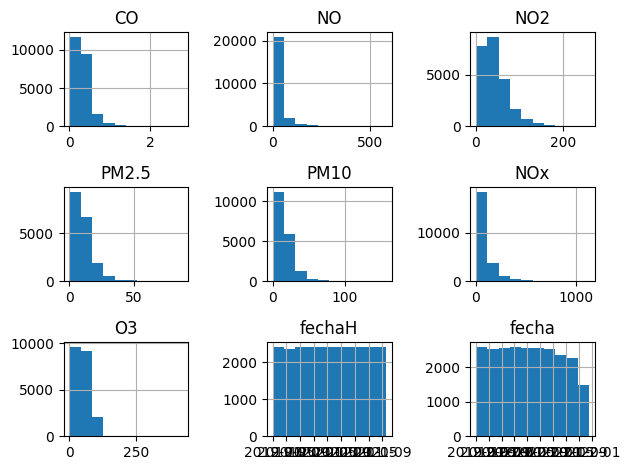

In [ ]:
import matplotlib.pyplot as plt
df.hist()
plt.tight_layout()
plt.show()

<Axes: ylabel='Frequency'>

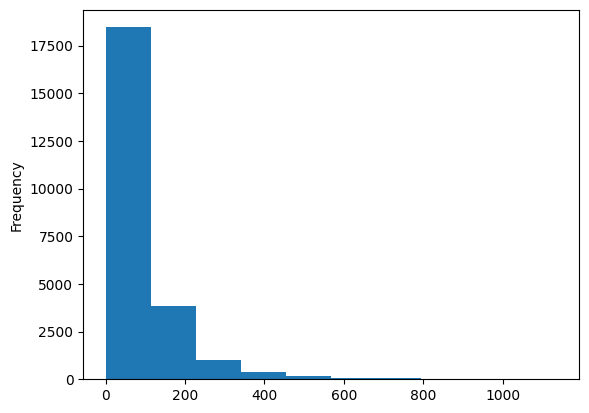

In [ ]:
df.NOx.plot(kind="hist")

Incluyendo la función de densidad:

<Axes: ylabel='Frequency'>

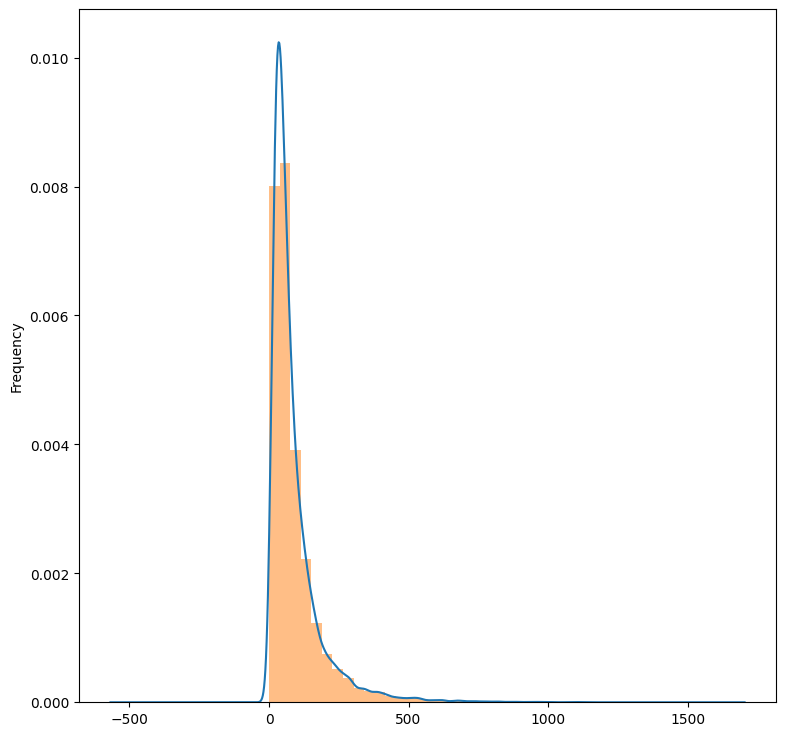

In [ ]:
df.NOx.plot(kind="density", figsize=(9,9))
df.NOx.plot(kind="hist", density=True, alpha=0.5, bins=30)

También podemos añadir la media y la mediana

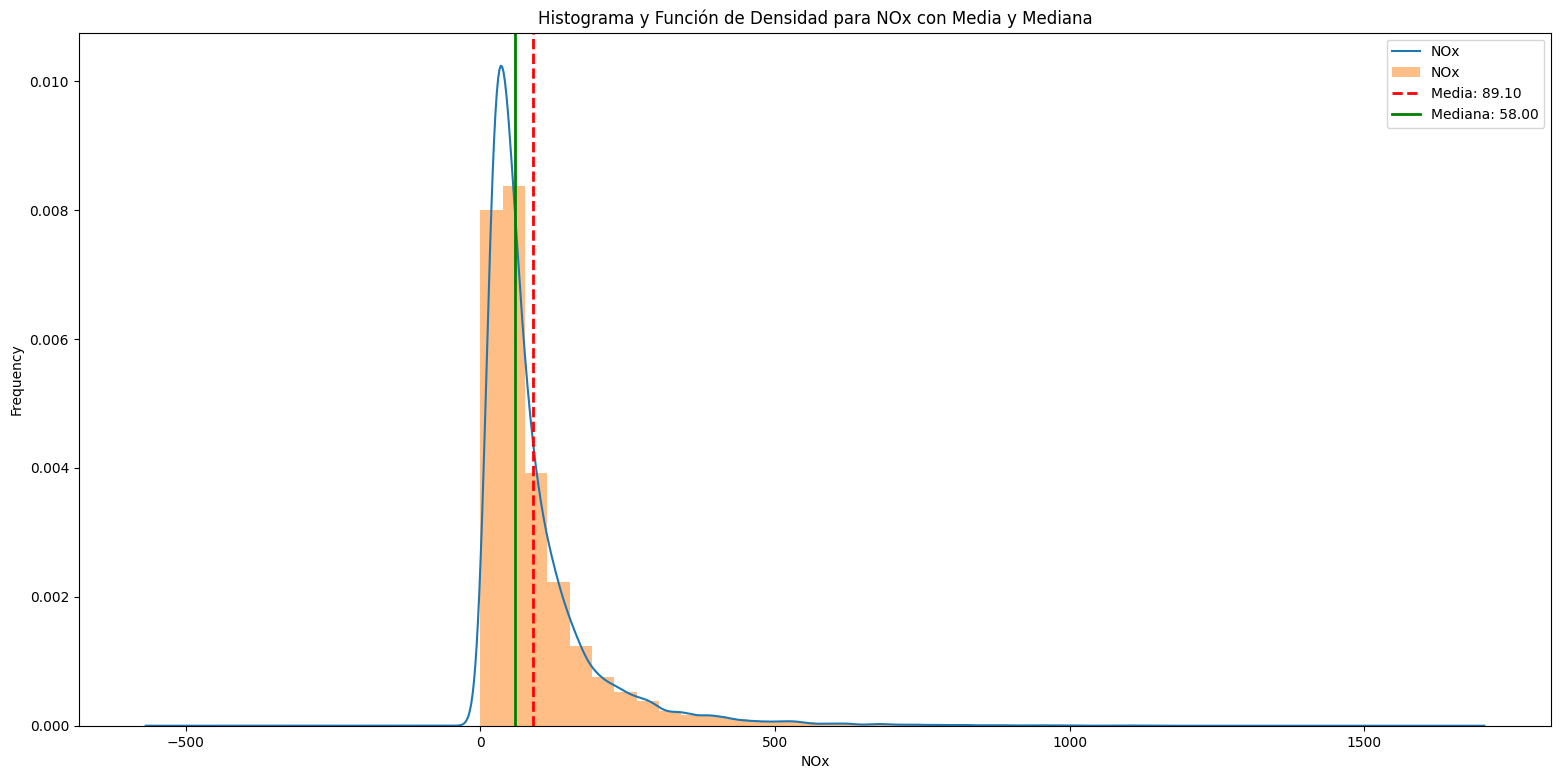

In [ ]:
df.NOx.plot(kind="density", figsize=(19,9))
df.NOx.plot(kind="hist", density=True, alpha=0.5, bins=30)

# Añadir líneas verticales para la media y la mediana
media = df.NOx.mean()
mediana = df.NOx.median()
plt.axvline(media, color='red', linestyle='--', linewidth=2, label=f'Media: {media:.2f}')
plt.axvline(mediana, color='green', linestyle='-', linewidth=2, label=f'Mediana: {mediana:.2f}')
plt.legend()
plt.xlabel('NOx')
plt.title('Histograma y Función de Densidad para NOx con Media y Mediana')
plt.show()

Con seaborn

<Axes: xlabel='NOx', ylabel='Count'>

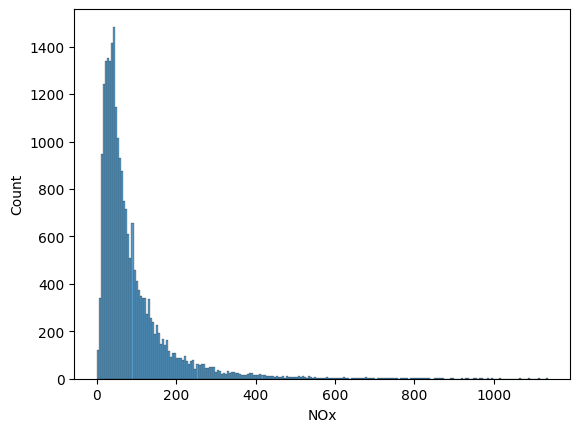

In [ ]:
import seaborn as sns
sns.histplot(df, x="NOx")

Con plotly

In [ ]:
import plotly.express as px
fig = px.histogram(df, x="NOx")
fig.show()


En el caso de ser strings o tipos categóricos lo que mostramos es el un diagrama de barras  del dataframe devuelto por `value_counts`:

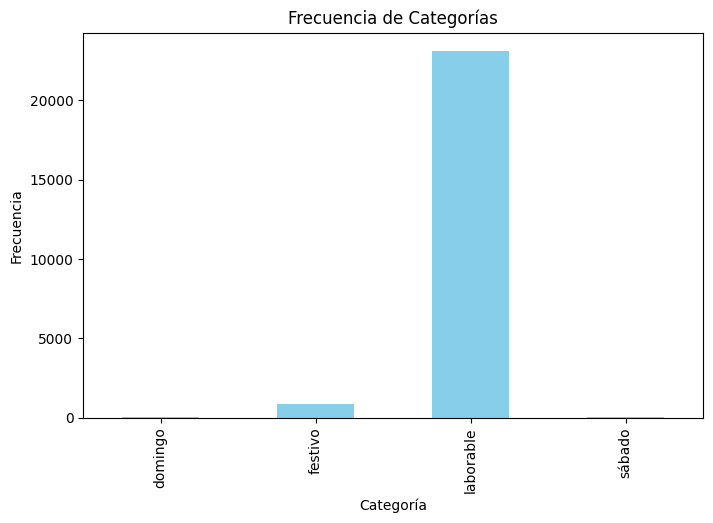

In [ ]:
frecuencias = df['festivo'].value_counts().sort_index()

# Crear un diagrama de barras usando pandas
frecuencias.plot(kind='bar', figsize=(8, 5), color='skyblue', title='Frecuencia de Categorías')
plt.xlabel('Categoría')
plt.ylabel('Frecuencia')
plt.show()

Con seaborn

<Axes: xlabel='festivo', ylabel='count'>

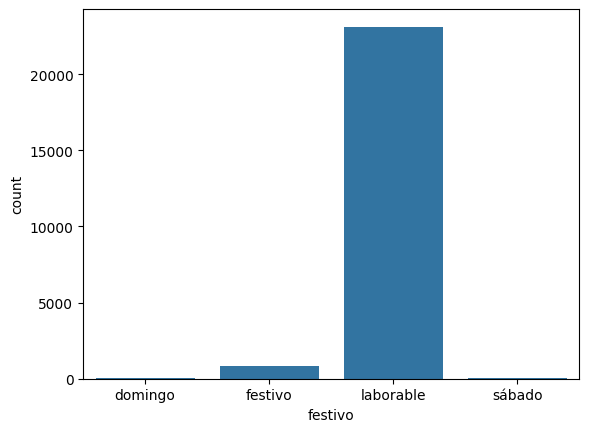

In [ ]:
import seaborn as sns
sns.countplot(data=df, x="festivo")

Con plotly

In [ ]:
fig = px.bar(frecuencias)
fig.show()

### 4.2 Diagramas de líneas

Los diagramas de puntos y los diagramas de líneas son un buen complemento de los histogramas, especialmente cuando son series temporales. Si este es el caso, tener la fecha como índice nos ayudará a que el gráfico se muestre ordenado por fecha.

In [ ]:
df = carga_conta() # para estar seguros de tener los datos adecuados


**Pandas**

<Axes: xlabel='fechaH'>

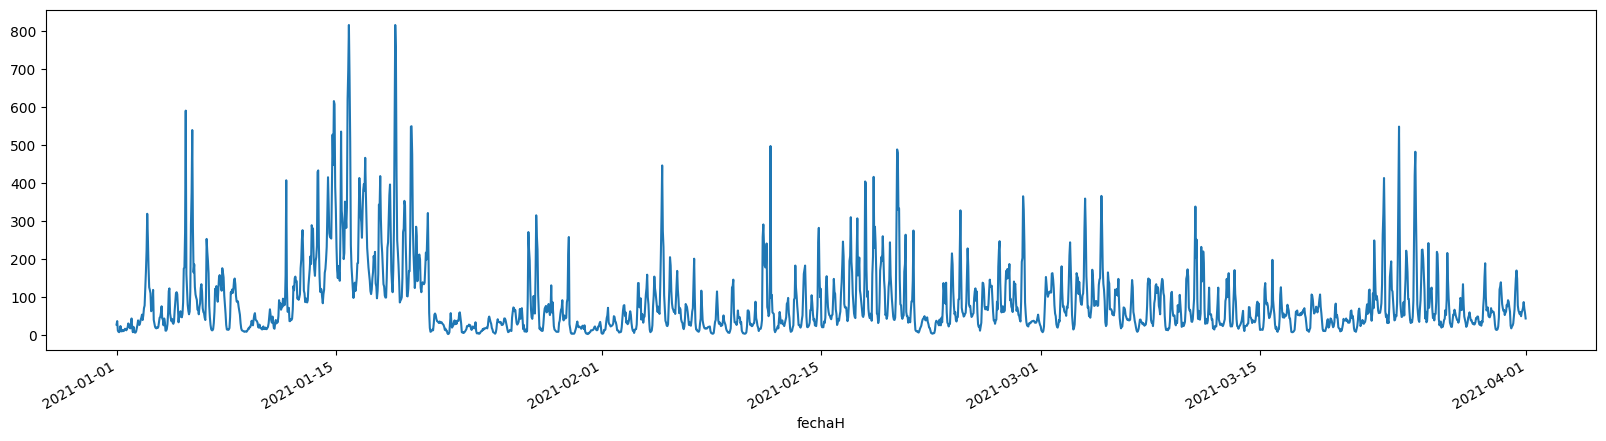

In [ ]:
filtro = (df.ANO==2021) & (df.MES<=3)
df[filtro].NOx.plot(kind="line", figsize=(20,5))

El gráfico de puntos es similar, pero exige que se lo apliquemos al dataframe completo e indiquemos como parámetros la x y la y...cosas de Pandas

<Axes: xlabel='fechaH', ylabel='NOx'>

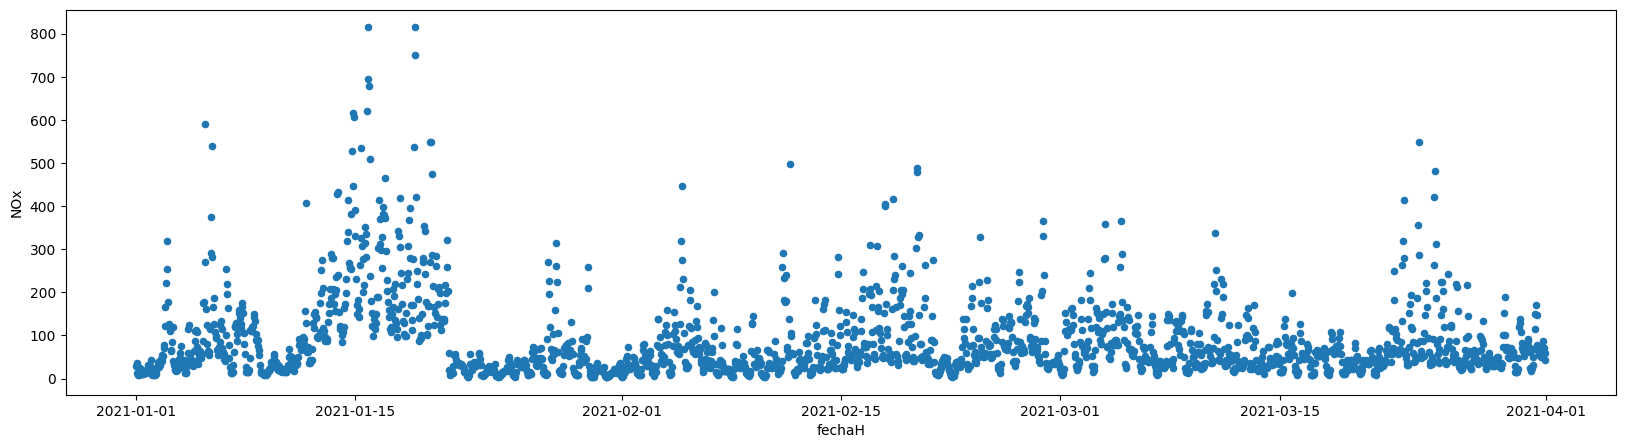

In [ ]:
df[filtro].plot(kind="scatter", x="fechaH", y="NOx", figsize=(20,5))
plt.show()

Con matplotlib directamente

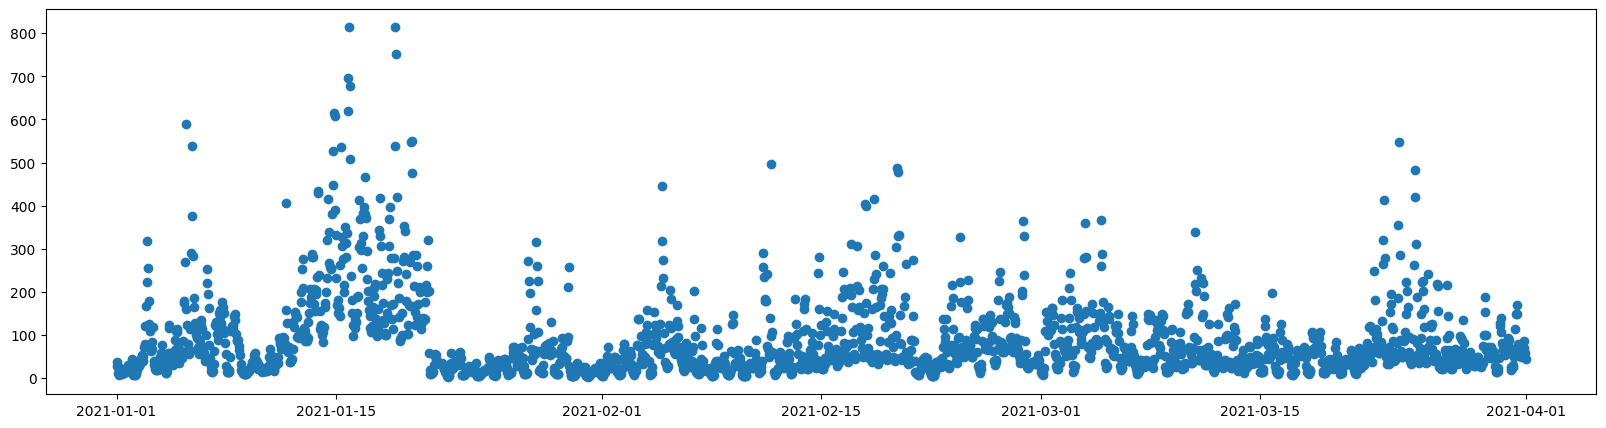

In [ ]:
datos = df[filtro]
plt.figure(figsize=(20, 5))
plt.scatter(x=datos["fechaH"], y=datos["NOx"])
plt.show()

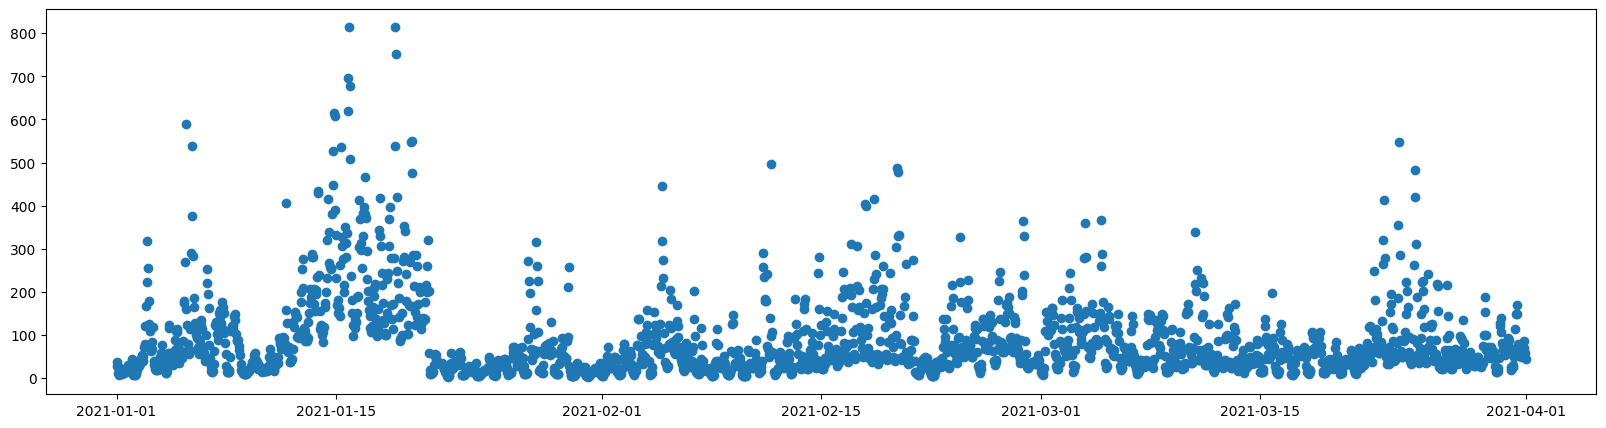

In [ ]:
datos = df[filtro]
plt.figure(figsize=(20, 5))
plt.scatter(x=datos["fechaH"], y=datos["NOx"])
plt.show()

plt tiene un mongón de opciones comunes para todos los gráficos, como plt.figure(), plt.show(),  plt.title(), plt.savefig()

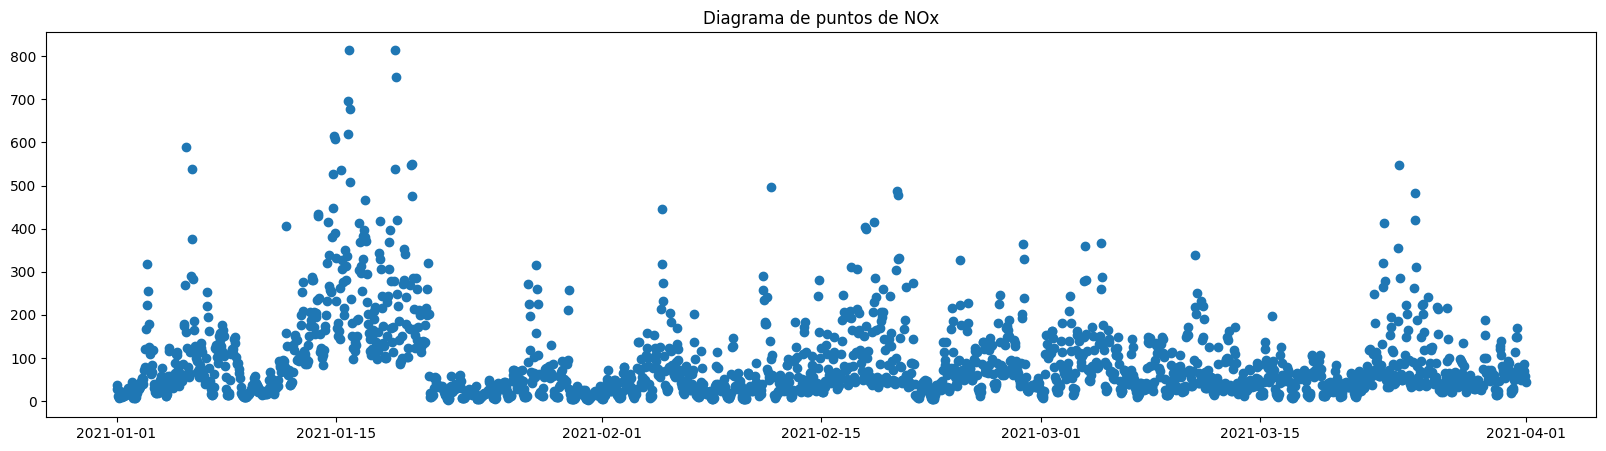

In [ ]:
datos = df[filtro]
plt.figure(figsize=(20, 5))
plt.scatter(x=datos["fechaH"], y=datos["NOx"])
plt.title("Diagrama de puntos de NOx")
plt.savefig("diagrama_nox.pdf", format="pdf", bbox_inches="tight", dpi=300)
plt.show()

<Axes: xlabel='fechaH', ylabel='NOx'>

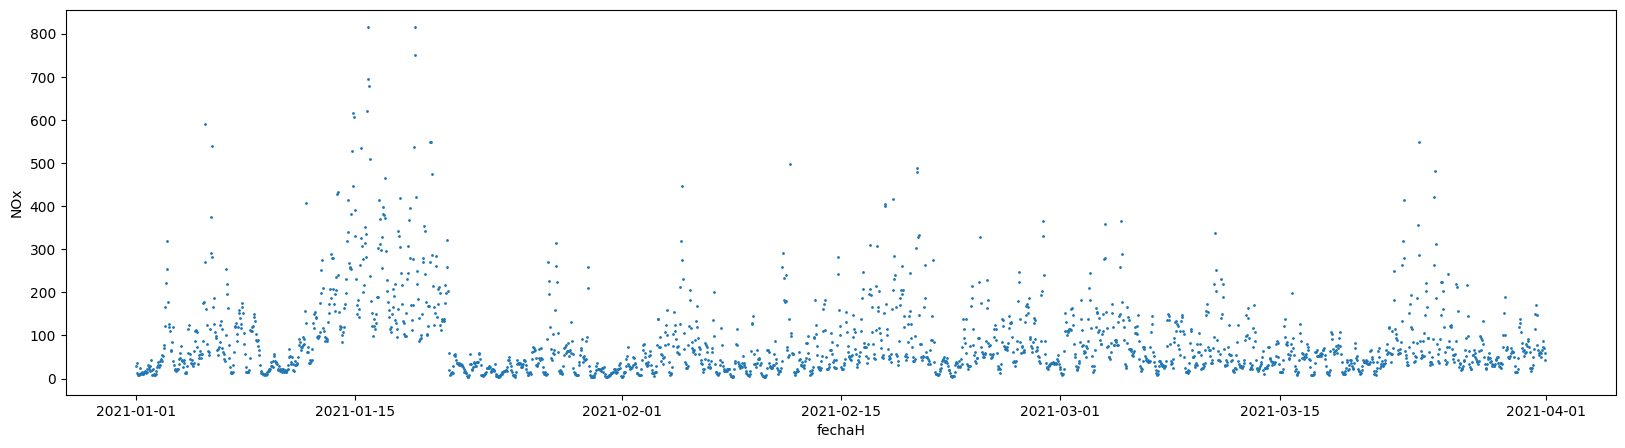

In [ ]:
# Añadimos tamaño del punto
plt.figure(figsize=(20, 5))
df[filtro].plot(kind="scatter", x="fechaH", y="NOx",s=1)

**seaborn**

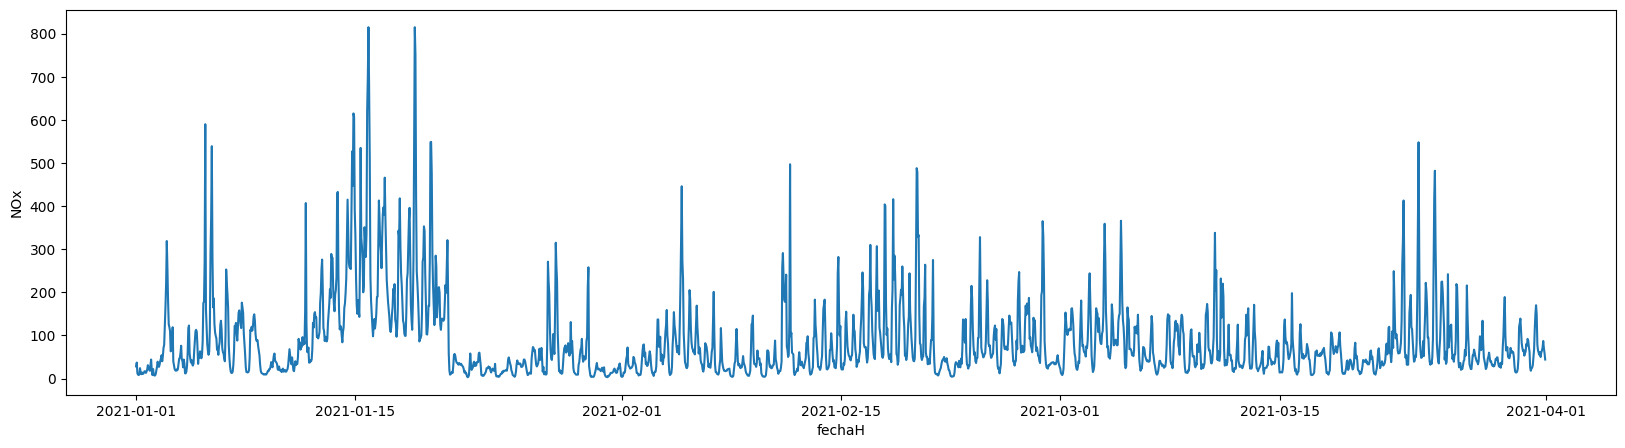

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 5))
sns.lineplot( data=df[filtro],   x='fechaH',    y='NOx')
plt.show()


In [ ]:
import plotly.express as px
import pandas as pd


# Crear el gráfico de líneas con Plotly

fig = px.line(df[filtro], x="fechaH",  y='NOx',  width=1000, height=500)

# Añadir detalles al gráfico
fig.update_layout(
    title='Gráfico de Líneas de NOx vs Fecha',
    xaxis_title='Fecha',
    yaxis_title='NOx',
    xaxis=dict(rangeslider=dict(visible=True)),  # Añadir un selector de rango de fecha si es necesario
    template='plotly_white'
)

# Mostrar el gráfico
fig.show()


<a id="Referencias"></a>
## 5. Referencias
---
[Medidas de centralidad](https://statistics.laerd.com/statistical-guides/measures-central-tendency-mean-mode-median.php)<br>
[Biblioteca ydata-profiling](https://pypi.org/project/ydata-profiling/)<br>

*Data Cleaning*. Ihab F. Ilyas and Xu Chu. Association for Computing Machinery 9781450371544 Tiene un capítulo dedicado a outliers muy completo

[Best Practices in Data Cleaning: A Complete Guide to Everything You Need to Do Before and After Collecting Your Data](http://pzs.dstu.dp.ua/DataMining/preprocessing/bibl/cleaning.pdf). Capítulo 7.
de Jason W. Osborne. Un poco técnico/estadístico pero  preciso
